# Install required libraries 

!pip install requests                       # A Python libarary for requesting data from a website
!pip install numpy==2.2.0                   # NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays        
!pip install pandas==2.2.3                  # Pandas is a software library written for the Python programming language for data manipulation and analysis.     
!pip install scikit-learn==1.6.0            # Open-source machine learning library for the Python programming language   
!pip install matplotlib==3.9.3              # Matplotlib is a plotting library for Python and pyplot gives us a Matlab like plotting framework. We will use this in our plotter function to plot data.

In [1]:
#==========================
# Import required libraries
#==========================

import io                         
import os                         
import requests                   
%matplotlib inline

# Import installed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                                   # Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics

In [ ]:
#==================================================================================================================
# IMPORT DATA FILES IN csv FORMAT FROM A WEBSITE, MERGE THE CONTENTS, AND SAVE IT IN A LOCAL DRIVE AS A csv FILE. 
# The main steps are summarized here:

# - Import data from a web site: it is asssumed that data is available as a CSV file and is imported file by file
# -  Data in each source file is read into a dataframe 
# - Each dataframe is then stored/appened into a list 
# - The contents of the list are merged into a larger dataframe
# - Merged data (dataframe) is saved into the local drive as a CSV file
#==================================================================================================================

csv_urls = ['https://example.com', 'https://example.com']                               # Create a list of strings to store the URLs from which the data files are to be extracted 
first_file_headers = None                        

# - The data used in the current project was imported from AZMET: Arizona Meteorlogical Network Website 
# - Six csv files were used in the current project and the URL from which each file is extracted is listed below 
# - Each file in the list contains hourly meteorological data and reference evapotranspiration (determined with the Penman-Monteith equation) covering a calendar year
# - Overall, the list consists of data spanning the period 01-01-2009 and 12-31-2014 in descending order
# - The list of URLs are defined in the exact order the respective files will be imported and eventually merged to form a single file:
 
csv_urls = [
                'https://azmet.arizona.edu/azmet/data/1409rh.txt',
                'https://azmet.arizona.edu/azmet/data/1410rh.txt',
                'https://azmet.arizona.edu/azmet/data/1411rh.txt',
                'https://azmet.arizona.edu/azmet/data/1412rh.txt',
                'https://azmet.arizona.edu/azmet/data/1413rh.txt',
                'https://azmet.arizona.edu/azmet/data/1414rh.txt' 
            ]

# Define the local destination for the merged file
output_file_path = r'C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\DataAquisitionPreparation\Data\TrainingAndTesting\2009_2014_Hourly.csv'

# The following code block downloads csv files, reads each data set into a dataframe, and append the dataframe into a list of dataframes
dataframes = []                                    # Create a list called dataframes

for url in csv_urls:
    print(f"Downloading: {url}")
    response = requests.get(url)                    # Make a request to extract data from the web site
    response.raise_for_status()                     # Ensures if request was sucessful 
    
    df = pd.read_csv(io.StringIO(response.text), header=None)    # Read the CSV content into a pandas DataFrame, df
    dataframes.append(df)                                        # Append the current data frame into the list 'dataframes' as a separate block  

# Concatenate all DataFrame blocks in order into a single dataframe and Save the merged dataframe to the local drive
merged_df = pd.concat(dataframes, ignore_index=True)
merged_df.to_csv(output_file_path, index=False, header=False)


In [31]:
# This step defines the directory path to the local folder where the CSV source file is located

# Note: I. This step is used only after data is safely imported and saved in the "output_file_path" and if a Kernel expires, 
#          Kernel restart was excuted, or a new session is started. In such scenarios, DO NOT EXECUTE the data downlaod and 
#          save operation coded in the above cell
#
#      II. Immediately following a data download operation this step is redundant - execution of this step is unnecessary.  

output_file_path = r'C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\DataAquisitionPreparation\Data\TrainingAndTesting\2009_2014_Hourly.csv'

In [32]:
# Import the input data (a csv file) from the directory path (output_file_path), read the csv file content into dataframe (WeatherEt_df), and print a sample 

WeatherEt_df=pd.read_csv(output_file_path)
WeatherEt_df

,av_hr_ta,av_vap_d,act_hr_vap,tot_sol_eng,soil_temp_5,soil_temp_10,av_wnd_spd,av_wnd_vel_dir,Eto
0,5.9,0.18,0.74,0.0,12.6,15.0,0.8,195.0,-0.01
1,5.7,0.18,0.74,0.0,12.3,15.0,0.3,80.0,-0.01
2,4.7,0.10,0.75,0.0,12.0,15.1,0.3,187.0,-0.02
3,3.8,0.10,0.70,0.0,11.7,15.1,0.5,188.0,-0.02
4,3.7,0.05,0.75,0.0,11.5,15.1,0.2,280.0,-0.02
...,...,...,...,...,...,...,...,...,...
52603,4.2,0.28,0.55,0.0,12.5,15.4,1.8,15.0,0.00
52604,3.4,0.23,0.55,0.0,11.8,15.4,0.5,280.0,-0.01
52605,1.7,0.14,0.55,0.0,11.1,15.4,0.6,205.0,-0.01
52606,1.3,0.15,0.52,0.0,10.4,15.4,1.2,148.0,-0.01


# Comment 

The data imported earlier consists 18 variables. Including 14 categories of meteorological data and 3 categories of temporal data, which together consititute the potential predictor variable set.
Reference evapotranspiration is the dependent variable 

Column Index 	    Column Header 	            Full Column Name	                    Unit

     1	            calend_year                  Calendar Year	                                -                    (temporal data)
     2	            d_of_year 	                 Day of Year	                                -                    (temporal data)
     3	            h_of_day                     Hour of Day                                    h                    (temporal data)
     
     4	            av_hr_ta	           Hourly Average Air temperature	                    oC
     5	            av_hr_rh	          Hourly Average Relative Humidity                      %	
     6	            av_vap_d            Hourly Average Vapor Pressure Deficit	                KPa
     7(17)	        act_hr_vap	        Actual Hourly Average Vapor Pressure                    KPa
     8(18)	        dwpt_hr_ta	        Hourly Average Dew Point Temperature	                oC
     9	            tot_sol_eng      Total Hourly Solar Energy Flux Per Square Meter            MJ/h-m^2 
    10           	tot_precip	             Total Hourly Precipitation	                        mm
    11              soil_temp_5       Hourly Average soil Temperature at 5cm Depth	            oC
    12         	    soil_temp_10	  Hourly Average soil Temperature at 10cm Depth	            oC
    13           	av_wnd_spd                Hourly Average Wind Speed	                        m/s
    14           	av_wnd_vel_mag	      Hourly Average Wind Vector Magnitude	                m/s
    15	            av_wnd_vel_dir	      Hourly Average Wind Velocity Direction	            degree
    16	            st_dev_wnd_dir	  Hourly Standard Deviation of Wind Velocity Direction  	degree
    17	            max_wnd_spd	              Hourly Maximum Wind Speed	                        m/s
    
    18	            Eto	                 Reference Hourly Evapotranspiration	                mm                   (dependent variable)  
 
 (*) The column index of the variables in the original data set. 


The variable set considered in the current analysis (see the dataframe above) consists of a subset of the above variable set, containing 8 metorological features, 
no temporal variable, and reference evapotranspiration - 10 variables in all:

Column Index 	    Column Header 	          Full Column Name	                       Unit

     1	            av_hr_ta	          Hourly Average Air Temperature	             oC  
     2	            av_vap_d             Hourly Average Vapor Pressure Deficit	         KPa
     3	            act_hr_vap	         Actual Hourly Average Vapor Pressure            KPa
     4	            tot_sol_eng            Total Hourly Solar Energy Flux                MJ/h-m^2
     5              soil_temp_5       Hourly Average soil Temperature at 5cm Depth       oC
     6         	    soil_temp_10	   Hourly Average soil Temperature at 10cm Depth	 oC
     7           	av_wnd_spd             	  Hourly Average Wind Speed	                 m/s
     8	            av_wnd_vel_dir	     Hourly Average Wind Velocity Direction	         degree
     9	            Eto	                   Hourly Reference Evapotranspiration	         mm

# Variables not considered in the current analysis:

1. All temporal variables were not carried over into the new variables set. Although seasonal and diurnal variation of evapotranspiration are related to the 
   temporal variables (Day of Year and Hour of day), it is assumed here that these influences on evapotranspiration are embedded in the seasonal and diurnal 
   patterns of variation of weather parameters. Thus, it is reasoned here that the pair of temporal variables (Day of Year and Hour of Day) can be dropped 
   from further consideration without compromising accuracy
          The variable, calendar year, could be considered a factor that encapsulates the effects of longer term global climatic variational patterns on local 
   weather and, hence, on Eto. However, as a first approximation, the model developed here will not consider those effects. The implication is that the prediction 
   accuracy of models trained on smaller data sets with consecutive calendar years may deteriorate when used on data that is significantly removed in time from 
   those of the training data sets   

3. The Hourly Average Vapor Pressure Deficit is related/correlated to the Hourly Average Air Temperature and the Actual Hourly Average Vapor Pressure. Each of these
   variables were included in the feature set considered in the initial data preparation phase. The goal is to perform further analysis and determine whether all
   of them need to be part of the eventual feature set (used in model development) or some subset could lead to sufficiently accurate model

4. The Hourly Average Relative Humidity variable was dropped from further consideration, because, it represents the same information as the Hourly Average Actual 
   Vapor Pressure
 
5. Based on intuitive physical reasoning, the influences of the following weather parameters 
   - Hourly Average Dew Point Temperature
   - Hourly Average Wind Vector Magnitude
   - Hourly Standard Deviation of Wind Velocity Direction, and
   - Hourly Maximum wind Speed
   
   on evapotranspiration were deemed marginal influence. Thus, they will not be not considered further! 

Data Wrangling

In [33]:
# Check data types of the dataframe columns and ensure consistency 

WeatherEt_df.dtypes

av_hr_ta          float64
av_vap_d          float64
act_hr_vap        float64
tot_sol_eng       float64
soil_temp_5       float64
soil_temp_10      float64
av_wnd_spd        float64
av_wnd_vel_dir    float64
Eto               float64
dtype: object

In [34]:
# Check if there are null values and their numebr in each column 

WeatherEt_df.isnull().sum()

av_hr_ta          3
av_vap_d          3
act_hr_vap        3
tot_sol_eng       3
soil_temp_5       3
soil_temp_10      3
av_wnd_spd        3
av_wnd_vel_dir    3
Eto               3
dtype: int64

In [35]:
# Data cleaning: Convert Null entries to NaN, Delete rows with NaN values, and Reset row index

WeatherEt_df = WeatherEt_df.replace('NULL', np.nan)
WeatherEt_df.dropna(inplace=True)
WeatherEt_df.reset_index(drop=True, inplace=True)
WeatherEt_df

,av_hr_ta,av_vap_d,act_hr_vap,tot_sol_eng,soil_temp_5,soil_temp_10,av_wnd_spd,av_wnd_vel_dir,Eto
0,5.9,0.18,0.74,0.0,12.6,15.0,0.8,195.0,-0.01
1,5.7,0.18,0.74,0.0,12.3,15.0,0.3,80.0,-0.01
2,4.7,0.10,0.75,0.0,12.0,15.1,0.3,187.0,-0.02
3,3.8,0.10,0.70,0.0,11.7,15.1,0.5,188.0,-0.02
4,3.7,0.05,0.75,0.0,11.5,15.1,0.2,280.0,-0.02
...,...,...,...,...,...,...,...,...,...
52600,4.2,0.28,0.55,0.0,12.5,15.4,1.8,15.0,0.00
52601,3.4,0.23,0.55,0.0,11.8,15.4,0.5,280.0,-0.01
52602,1.7,0.14,0.55,0.0,11.1,15.4,0.6,205.0,-0.01
52603,1.3,0.15,0.52,0.0,10.4,15.4,1.2,148.0,-0.01


In [36]:
# Check the dimensions of the cleaned dataframe 

WeatherEt_df.shape

(52605, 9)

In [37]:
# Check if there are null values in the cleaned datafram 

WeatherEt_df.isnull().sum()

av_hr_ta          0
av_vap_d          0
act_hr_vap        0
tot_sol_eng       0
soil_temp_5       0
soil_temp_10      0
av_wnd_spd        0
av_wnd_vel_dir    0
Eto               0
dtype: int64

In [38]:
# Check data types once more

WeatherEt_df.dtypes

av_hr_ta          float64
av_vap_d          float64
act_hr_vap        float64
tot_sol_eng       float64
soil_temp_5       float64
soil_temp_10      float64
av_wnd_spd        float64
av_wnd_vel_dir    float64
Eto               float64
dtype: object

In [39]:
# Get the summary statistics for each variable of the dataframe 

WeatherEt_df.describe()

,av_hr_ta,av_vap_d,act_hr_vap,tot_sol_eng,soil_temp_5,soil_temp_10,av_wnd_spd,av_wnd_vel_dir,Eto
count,52605.000000,52605.000000,52605.000000,52605.000000,52605.000000,52605.000000,52605.000000,52605.000000,52605.000000
mean,22.142321,1.963839,1.142830,0.850573,25.404155,24.992683,2.008410,191.968102,0.232649
std,9.870279,1.688360,0.588984,1.116016,9.204539,6.994124,1.586842,101.974838,0.286109
min,-4.300000,0.000000,0.100000,0.000000,5.000000,10.300000,0.200000,1.000000,-0.030000
25%,14.400000,0.660000,0.720000,0.000000,17.500000,18.300000,0.800000,125.000000,0.020000
50%,21.800000,1.450000,1.000000,0.050000,25.400000,25.200000,1.500000,201.000000,0.080000
75%,29.700000,2.810000,1.400000,1.730000,33.000000,31.900000,2.800000,270.000000,0.410000
max,46.300000,9.590000,3.530000,3.820000,46.900000,36.800000,13.000000,360.000000,1.240000


Exploratory data analysis

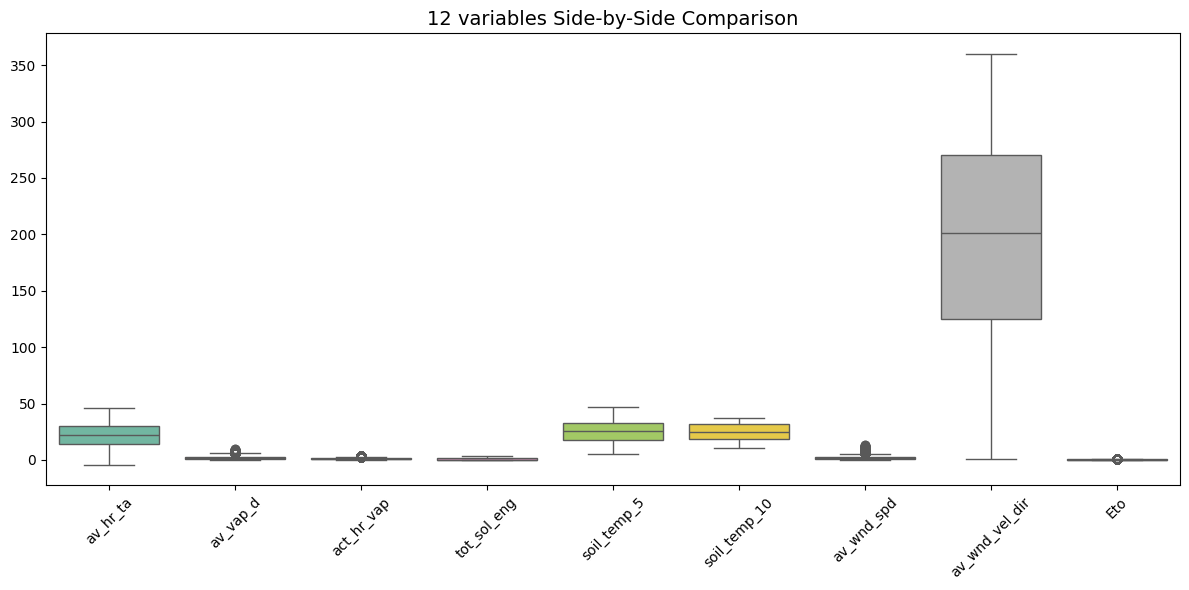

In [41]:
# Display side by side box plots for all the variables 

# Plot all 12 columns side-by-side
plt.figure(figsize=(12, 6))
sns.boxplot(data=WeatherEt_df, palette="Set2")

plt.title("12 variables Side-by-Side Comparison", fontsize=14)
plt.xticks(rotation=45)                                        
plt.tight_layout()
plt.show()

# Comment

- The Hourly average temperature, av_hr_ta, is slight left-skewed 
- The Hourly average soil temperature at 5 and 10cm depths, soil_temp_5 and soil_temp_10, and the average wind velocity direction, av_wnd_vel_dir, show symmetric distribution about the mean
- The Average hourly wind velocity direction is exceeds some variables by several folds and many by orders of magnitude. As a result, the distribution of the remaining set of variables is 
  not readily discernible. However, it can be noted that av_vap_d, act_hr_vap, and av_wnd_spd have significant right tails, suggesting the existence of outlier data points at the upper end of 
  the data range.

Following further analysis and feature selection, we will try to have a second look at the side-by-side box plots - perhaps scale effects could reduced and data distribution could be more 
readily discernible  

C:\Users\dawit\AppData\Local\Temp\ipykernel_25992\1795931105.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_sorted.index,


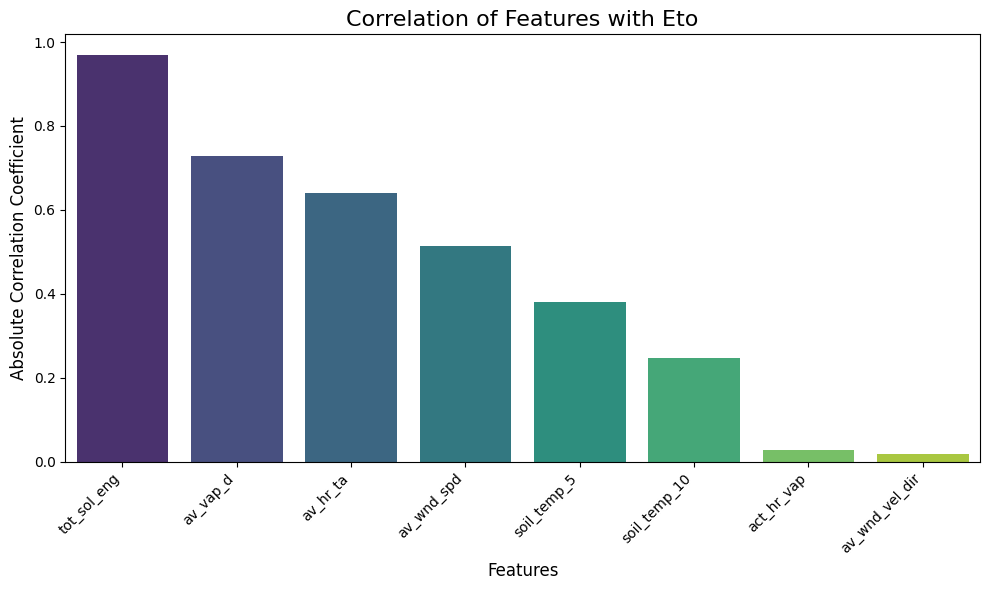

In [42]:
# CALCULATE CORRELATION and plot it 

# Compute correlation of all columns with the target and drop the target's self-correlation
targ_var = 'Eto'
correlations = WeatherEt_df.corr()[targ_var].drop(targ_var)

# Sort correlations by magnitude (absolute value) to make the chart easy to read
correlations_sorted = correlations.abs().sort_values(ascending=False)

# PLOTTING CORRELATION DATA AS A BAR CHART

plt.figure(figsize=(10, 6))

# Create a barplot (using the sorted index)
sns.barplot(x=correlations_sorted.index, 
            y=correlations_sorted.values, 
            palette='viridis')

# Add titles and labels
plt.title(f'Correlation of Features with {targ_var}', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute Correlation Coefficient', fontsize=12)

# Rotate feature labels if they are long
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Comment

The above histogram shows that with a correlation coefficient of about 0.97, reference evapotranspiration has (by far) the strongest correlation with Hourly Total Solar Energy Flux. 
Followed by vapor pressure deficit (correlation coefficient of 0.73), air temperature (0.64), wind speed (0.52), and soil temperature at 5cm depth (0.38), and soil temperature at 10cm depth (0.25)

The chart also shows that Actual Hourly Vapor Pressure and Hourly Average Wind Direction are poorly correlated with the reference evapotranspiration (correlation coefficients at or under 0.03)

In [ ]:
weather_df.columns

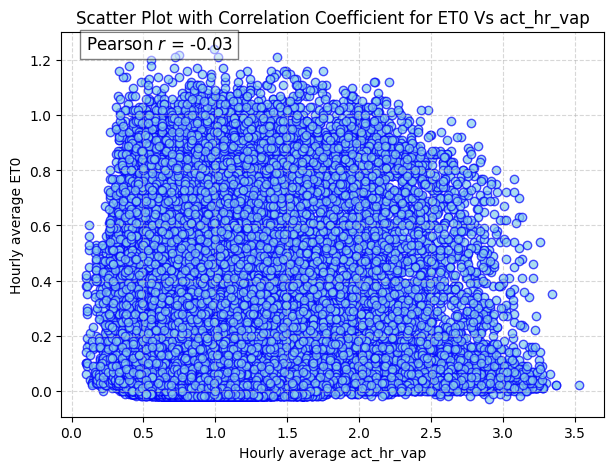

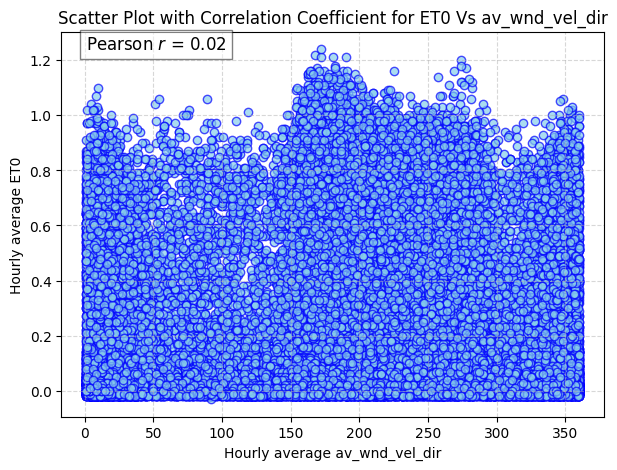

In [43]:
import scipy.stats as stats

# Calculate the Pearson correlation coefficient (r)

dep_var = WeatherEt_df['Eto'].to_numpy()
limit = 2
for i in range(limit):
   match i:
       case 0:
           x = 'act_hr_vap'
       case 1:
           x = 'av_wnd_vel_dir'     
   feature = WeatherEt_df[x].to_numpy()
  
   r_value, p_value = stats.pearsonr(feature, dep_var)
    
   # Create the scatter plot
   plt.figure(figsize=(7, 5))
   plt.scatter(feature, dep_var, color='skyblue', alpha=0.7, edgecolors='b', label='Data points')
    
   # Add labels, title, and the r-value annotation
   
   plt.xlabel(f"Hourly average {x}")   
   plt.ylabel('Hourly average ET0')   
   plt.title(f"Scatter Plot with Correlation Coefficient for ET0 Vs {x}")
   plt.text(min(feature), max(dep_var), f"Pearson $r$ = {r_value:.2f}", 
            fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
   
   plt.grid(True, linestyle='--', alpha=0.5)
   plt.show()

# Comment

There is no clearly discernible correlation between Actual Hourly Vapor Pressure and evapotranspiration and between the Hourly Average Wind Direction
and evapotranspiration. Eto shows significant spread at any given Actual Hourly Vapor Pressure or Hourly Average Wind Direction. This shows that the 
effect of these variables on Eto are highly modulated by other variables. To assess the validity of these conjuncture we will conduct multivariable 
correlation analysis

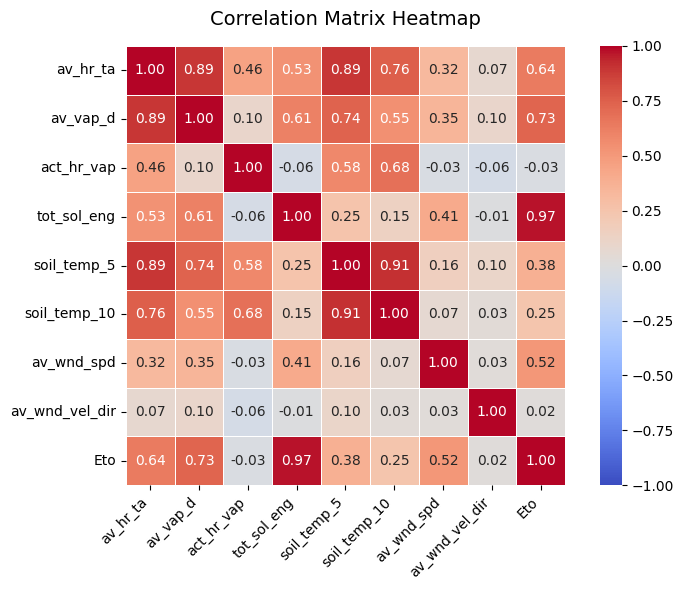

In [44]:
# Calculate the correlation matrix
# 'numeric_only=True' ensures it skips non-numeric columns if present
correlation_matrix = WeatherEt_df.corr(numeric_only=True)

# Configure the visual layout
plt.figure(figsize=(8, 6))

# Generate the heatmap with styling enhancements
sns.heatmap(
                correlation_matrix,
                annot=True,               # Displays the correlation value in each cell
                fmt=".2f",                # Formats numbers to 2 decimal places
                cmap="coolwarm",          # Diverging color palette (red=positive, blue=negative)
                vmin=-1,                  # Minimum value anchoring the color scale
                vmax=1,                   # Maximum value anchoring the color scale
                square=True,              # Forces cells to be perfectly square
                linewidths=0.5,           # Adds thin white gridlines between cells
           )

# Final adjustments
plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")                           # Rotates labels to avoid overlap
plt.yticks(rotation=0)
plt.tight_layout()

# Render the plot
plt.show()

# DISCUSSION ON VARIABLE SIGNIFICANCE

# Actual Hourly Average Vapor Pressure (act_hr_vap) and Hourly Average Wind Direction (av_wnd_vel_dir):

The heat-map above summarizes multivariable linear correlation between the variables. Overall, results from the correlation matrix support what has been observed earlier based on the 
outcome of bivariate linear correlation analysis: actual vapor pressure and wind direction are the variables with the least influence on reference evapotranspiration. The correlation 
matrix, however, reveals additional information. It shows the level of correlation between each feature and the rest of the feature set and as such it provides explanations why some 
features are more impactful than others in so far as their effects on evapotranspiration is concerned 

Actual vapor pressure (act_hr_vap): 

Actual hourly vapor pressure (act_hr_vap) shows significant correlation with soil temperature (0.58 for soil_temp_5 and 0.68 for soil_temp_10) and exhibits appreciable correlation 
with av_hr_ta (0.46) 

Average wind direction (av_wnd_vel_dir): 

Hourly Average Wind Velocity Direction (av_wnd_vel_dir) invariably shows extremely low correlation with each of the other features. The correlation coefficients between av_wnd_vel_dir 
and each of the other features averaged about 0.05

# Conclusion

These observations coupled with the results from the correlation histogram and the scatter plots shown earlier suggest:

- The negligibly small influence of actual vapor pressure (act_hr_vap) on Eto is likely related to the fact its effect is largely accounted for by soil temperature and to a lesser extent
  by air temperature - variables with which act_hr_vap shows strong correlation 
- Wind velocity direction (av_wnd_vel_dir) showed negligible interaction with the other features and insignificant effect on Eto
- Based on these observations the features, act_hr_vap and av_wnd_vel_dir, will be dropped from the feature set    

- Based on physical reasoning and data analysis we have now reduced the feature set to six variables:

Column Index 	    Column Header 	          Full Column Name	                       Unit

     1	            av_hr_ta	          Hourly Average Air Temperature	             oC  
     2	            av_vap_d             Hourly Average Vapor Pressure Deficit	         KPa   
     3	            tot_sol_eng            Total Hourly Solar Energy Flux                MJ/h-m^2
     4              soil_temp_5       Hourly Average soil Temperature at 5cm Depth       oC
     5         	    soil_temp_10	   Hourly Average soil Temperature at 10cm Depth	 oC
     6           	av_wnd_spd             	  Hourly Average Wind Speed	                 m/s
     7	            Eto	                   Hourly Reference Evapotranspiration	         mm



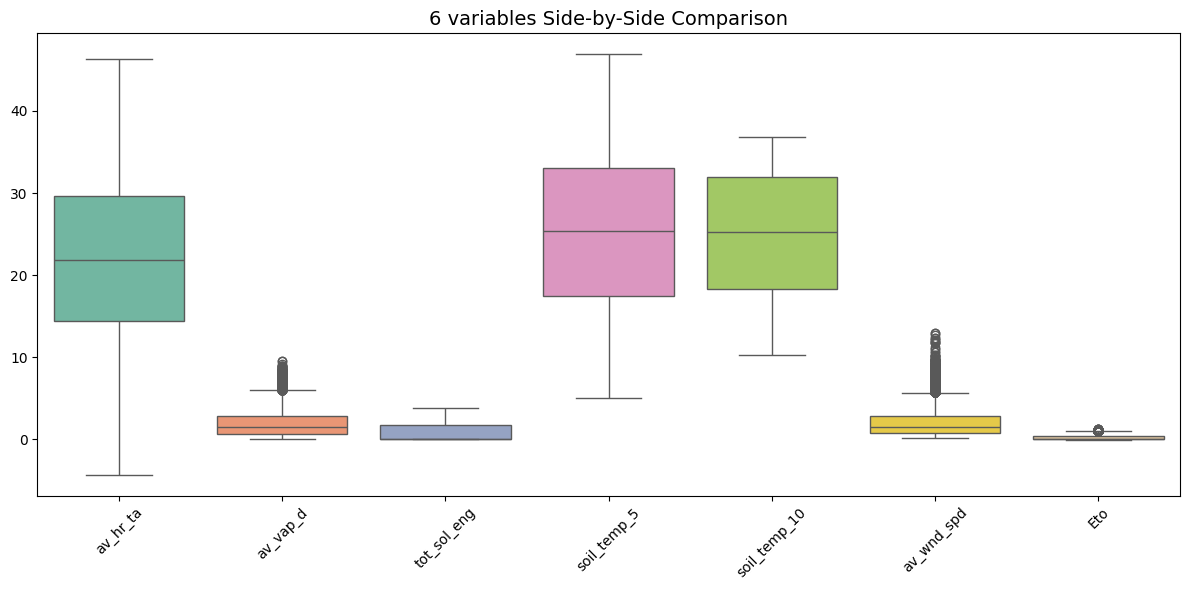

In [51]:
# Display side by side box plots for all the NEW VARIABLE SET

fin_feature_set= WeatherEt_df[['av_hr_ta', 'av_vap_d', 'tot_sol_eng', 'soil_temp_5', 'soil_temp_10', 'av_wnd_spd', 'Eto']]

# Plot all 7 columns side-by-side
plt.figure(figsize=(12, 6))

sns.boxplot(data=fin_feature_set, palette="Set2")

plt.title("6 variables Side-by-Side Comparison", fontsize=14)
plt.xticks(rotation=45)                                        
plt.tight_layout()
plt.show()

# Comment 

- The av_hr_ta, soil_temp_5, and soil_temp_10 data are symmetrically distributed about the mean
- The data for each of the other three variables (av_vap_d, tot_sol_eng, and av_wnd_spd) are biased right
- av_vap_d and av_wnd_spd contain significant cluster of outliers in the upper ranges of the data 
- Eto distribution is also biased high and have some outliers

Conclusion: 

Given that, in this project, there are no missing data that needs to be replaced, the information on distributional symmetry is not as such useful in that regard. 
The presence of significant amount of outlier in the av_vap_d and av_wnd_spd data sets, however, is a concern, because it can impair the efficiency of optimization 
processes and prediction accuracy of the resultant model

Because of time constraint we will not deal with outliers here!

Modeling phase starts here

In [52]:
# Set the traget variable to the reference evapotranspiration column and convert it to a numpy array

dep_v = WeatherEt_df['Eto'].to_numpy()
dep_v

array([-0.01, -0.01, -0.02, ..., -0.01, -0.01, -0.01], shape=(52605,))

In [53]:
# Define the feature (indepedent variable) set

X = WeatherEt_df[['av_hr_ta', 'av_vap_d', 'tot_sol_eng', 'soil_temp_5', 'soil_temp_10', 'av_wnd_spd']]
X

,av_hr_ta,av_vap_d,tot_sol_eng,soil_temp_5,soil_temp_10,av_wnd_spd
0,5.9,0.18,0.0,12.6,15.0,0.8
1,5.7,0.18,0.0,12.3,15.0,0.3
2,4.7,0.10,0.0,12.0,15.1,0.3
3,3.8,0.10,0.0,11.7,15.1,0.5
4,3.7,0.05,0.0,11.5,15.1,0.2
...,...,...,...,...,...,...
52600,4.2,0.28,0.0,12.5,15.4,1.8
52601,3.4,0.23,0.0,11.8,15.4,0.5
52602,1.7,0.14,0.0,11.1,15.4,0.6
52603,1.3,0.15,0.0,10.4,15.4,1.2


In [59]:
# Split the feature set and the target variable into train and test data sets, set test set to 20% of the whole data set
# Chronological Split (Upstream - As done before)

split_index = int(len(X) * 0.80)
X_train, X_test = X[:split_index], X[split_index:]
dep_v_train, dep_v_test = dep_v[:split_index], dep_v[split_index:]

Create a machine learning model pipe-line

In [60]:
# Create a GridSerachCrossValidation pipline for a Regression Tree model 

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import set_config

# The classes TimeSeriesSplit and GridSearchCV are imported from sklearn library providing the funcitonalities (1) to split data in chronological 
# order into training and testing data and (2) to enable GridSearch cross validation optimization during model training
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Display diagram of the GridSearchCV pipeline
set_config(display="diagram")                                          

tscv = TimeSeriesSplit(n_splits=5)
# Initialize and train the Regression Tree model
RegTree = DecisionTreeRegressor(random_state=60)

# Define the parameter grid
parameters = {
                'criterion': ['squared_error'],
                'splitter': ['best', 'random'],
                'max_depth': [None] + [2 * n for n in range(1, 10)], 
                'max_features': [None, 'sqrt'],
                'min_samples_leaf':[1, 2, 4],
                'min_samples_split': [2, 5, 10]              
            } 

"""
parameters = {
                'criterion': ['squared_error', 'absolute_error'],
                'splitter': ['best', 'random'],
                'max_depth': [None] + [2 * n for n in range(1, 10)], 
                'max_features': [None, 'sqrt', 'log2', 0.5],
                'min_samples_leaf':[1, 2, 4, 8],
                'min_samples_split': [2, 5, 10, 20]              
            }
"""

# Define multiple metrics as a list of strings
scoring_metrics = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']
# Define a GridSerahcCV object and intialize it 
RegTree_cv = GridSearchCV(
                             estimator = RegTree,                     
                             param_grid =parameters,                                                                                                             
                             verbose=2,                                # intermediate level of logging
                             n_jobs=-1,                                # instructs the computer to use all available CPU cores. 
                             cv = tscv,
                             scoring=scoring_metrics,                          #scoring='r2',                            # scoring method is r^2  
                             refit = 'r2'  
                          )
RegTree_cv.fit(X_train, dep_v_train)                               # Fit a GridSearchCV object to the training data using the 

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=DecisionTreeRegressor(random_state=60), n_jobs=-1,
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [None, 2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             refit='r2',
             scoring=['r2', 'neg_root_mean_squared_error',
                      'neg_mean_absolute_error'],
             verbose=2)

In [62]:
# Model Performance 

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error 

# Print the results
print(f"Best R2 Score from Grid Search: {RegTree_cv.best_score_:.4f}")
print(f"Best Hyperparameters: {RegTree_cv.best_params_}")

# Evaluate the best model on final test data
best_model = RegTree_cv.best_estimator_
dep_v_pred = RegTree_cv.predict(X_test)
test_r2 = r2_score(dep_v_test, dep_v_pred) # .score() on a regressor defaults to R2
test_rmse = root_mean_squared_error(dep_v_test, dep_v_pred)
test_mae = mean_absolute_error(dep_v_test,dep_v_pred)
test_av = np.mean(dep_v_pred)
print(f"Final Test R2 Score: {test_r2:.4f}")
print(f"Final Test rmse: {test_rmse:.4f}")
print(f"Final Test mae: {test_mae:.4f}")
print(f"Mean of predicted ET0: {test_av:.4f}")
#print(f"Final Test R2 Score: {test_neg_mean_absolute_error:.4f}")

Best R2 Score from Grid Search: 0.9964
Best Hyperparameters: {'criterion': 'squared_error', 'max_depth': 18, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}
Final Test R2 Score: 0.9978
Final Test rmse: 0.0127
Final Test mae: 0.0073
Mean of predicted ET0: 0.2128


Comment

R2 values equal or exeeding 0.995 suggest that model prediction are near perfect for both the training and test sets
The fact that R2 value of the test set is slightly greater than that of the training set suggests there is no risk of overfitting
The mean absolute error, mae, is about 4% of the average ET0

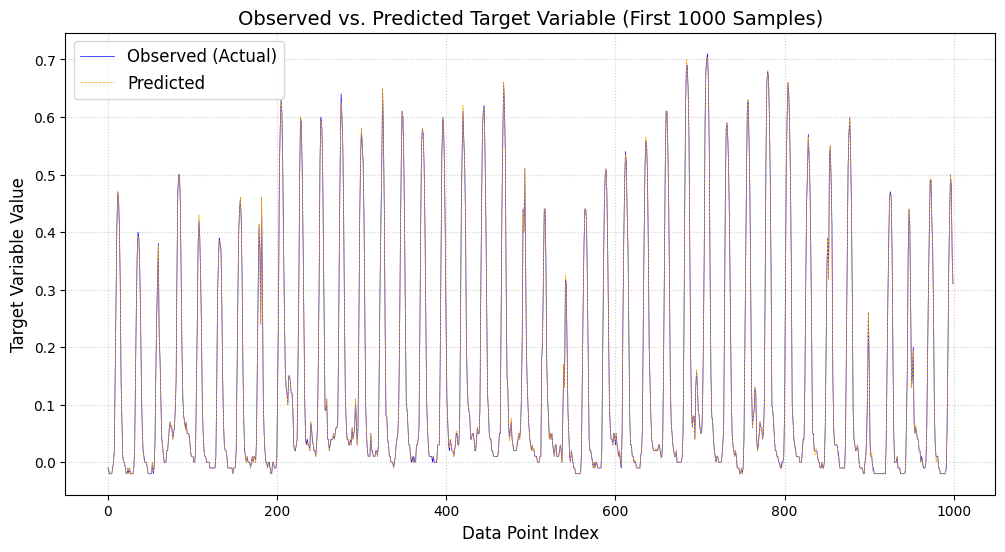

In [64]:
# Visual comparison of model predictions and observed data for the training data  

# Get the predicted values from your best model
dep_v_pred = RegTree_cv.predict(X_train)

# Reset indices so they align from 0 to the end
# (This ensures the plot matches up correctly)
observed = np.array(dep_v_train)
predicted = np.array(dep_v_pred)

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot the first 50 points so the chart is clean and scannable
plt.plot(observed[:1000], label='Observed (Actual)', color='blue', linewidth=0.5)
plt.plot(predicted[:1000], label='Predicted', color='orange', linestyle='--', linewidth=0.5)

# 4. Add labels, title, and legend
plt.title('Observed vs. Predicted Target Variable (First 1000 Samples)', fontsize=14)
plt.xlabel('Data Point Index', fontsize=12)
plt.ylabel('Target Variable Value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Show the chart
plt.show()

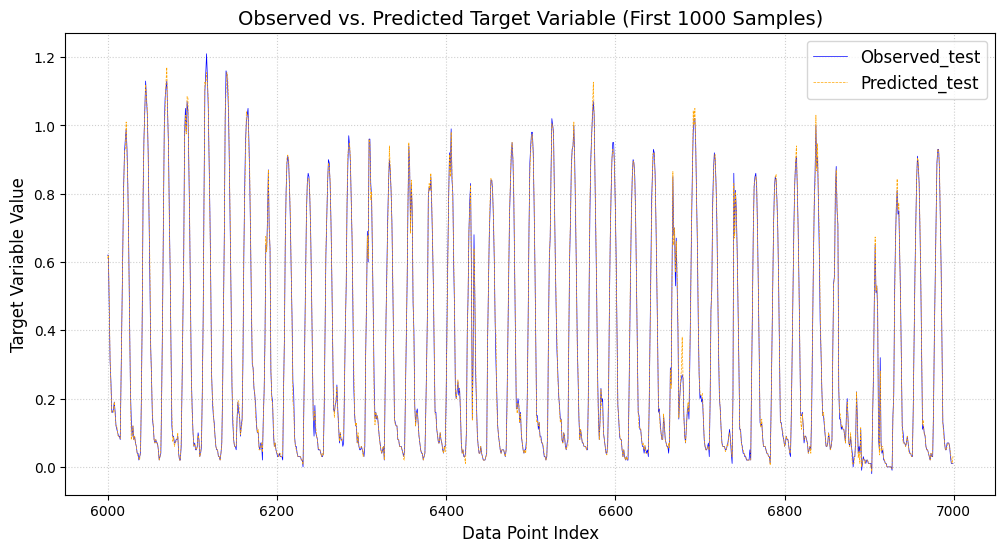

In [65]:
# Visual comparison of model predictions and observed data for the test data 

# Get the predicted values from your best model
dep_v_test_pred = RegTree_cv.predict(X_test)

# Reset indices so they align from 0 to the end
# (This ensures the plot matches up correctly)
observed_test = np.array(dep_v_test)
predicted_test = np.array(dep_v_test_pred)

X_test_index = range(6000, 7000)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the first 1000 points so the chart is clean and scannable
plt.plot(X_test_index, observed_test[6000:7000], label='Observed_test', color='blue', linewidth=0.5)
plt.plot(X_test_index, predicted_test[6000:7000], label='Predicted_test', color='orange', linestyle='--', linewidth=0.5)

# Add labels, title, and legend
plt.title('Observed vs. Predicted Target Variable (First 1000 Samples)', fontsize=14)
plt.xlabel('Data Point Index', fontsize=12)
plt.ylabel('Target Variable Value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Show the chart
plt.show()

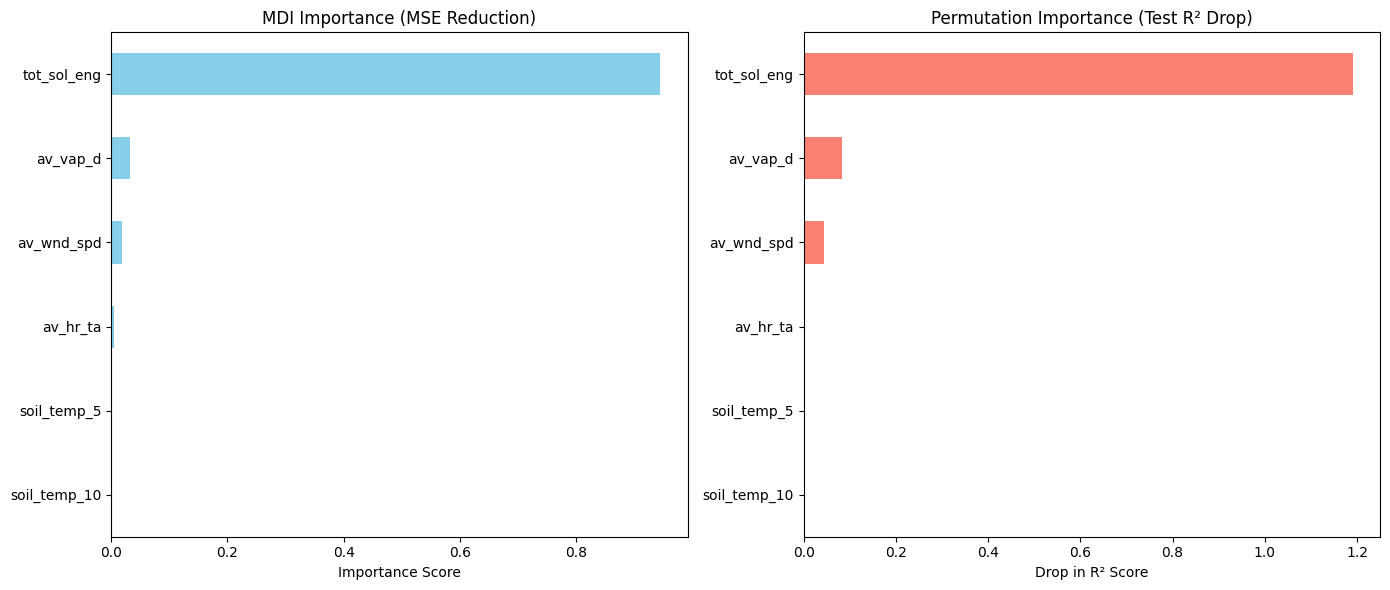

In [66]:
# Extract Feature importance

from sklearn.inspection import permutation_importance

# Assuming 'model' is your trained DecisionTreeRegressor 
# and 'feature_names' is a list of your column names

# Convert X_train_scaled back into a DataFrame
X_train_df = pd.DataFrame(
                                    X_train, 
                                    columns=X_train.columns, 
                                    index=X_train.index
                                )
feature_names = X_train_df.columns

# Calculate Built-in MDI Importance
mdi_importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=True)

# 2. Calculate Permutation Importance on Test Data
perm_result = permutation_importance(best_model, X_test, dep_v_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=True)

# Plotting the comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

mdi_importances.plot(kind='barh', ax=ax[0], color='skyblue')
ax[0].set_title("MDI Importance (MSE Reduction)")
ax[0].set_xlabel("Importance Score")

perm_importances.plot(kind='barh', ax=ax[1], color='salmon')
ax[1].set_title("Permutation Importance (Test R² Drop)")
ax[1].set_xlabel("Drop in R² Score")

plt.tight_layout()
plt.show()

# Comment

Summary of Results


Mean Decrease Impurity (MDI) Importance Chart - Training Phase
- The Mean Decrease Impurity (MDI) importance score quantifies how much a given feature contributes to reducing impurity (typically measured in terms of mean squared error) across the regression tree
- The MDI importance chart reveals that: MDI for Hourly Total Solar Energy Flux is 0.97, about 0.4 for the Hourly Average Vapor Pressure Deficit, and  0.2 for Hourly Average Wind Speed
- The rest of the variables appears to have almost no contribution to the redcution of variance during model training 
- This shows that the solar energy flux is by far the most important variable, with vapor presssure deficit and wind speed making marginal contributions 

Permuation Importance Chart - Testing Phase 
- The permuation importance chart above quantifies the reduction in the test R^2 of the model as a result of random shuffling of the respective data
- The chart shows that the R^2 of the model fell by 1.25 for solar energy, by 0.06 for vapor pressure deficit, and 0.03 for wind speed
- For the rest of the variables R^2 stayed unaffected through random shuffling of the respective data.
- This implies that hourly total solar energy input is by far the most is the principal predictor of evapotranspiration in the decision tree model developed here

Note: the fact that the test set based permutation importance reflects the training MDI implies model stability - that over fitting risk is low.

# Discussion 

Results of the preceding analysis suggest that dropping the average air temperature and soil temperature profile variables entirely from the feature set will have little or no effect on model performance!

# Air Temperature data 

- It appears that air temperature can be dropped from the feature set without impacting the predictive performance of the base model: Regression Tree model
- Physics based reasoning suggest that the effect of temperature on evapotranspiration is to an extent embedded in vapor pressure deficit and solar energy flux.
  Although physical reasoning appears to support the results of the preceding analysis, additional empirical evidence leads to a different conclusion.
- The author compared the performance of the base model (regression tree model) under two scenarios: (i) A training data that contains data on all the features but
  air temperature and (ii) A training data set consisting of the data used in scenario (i) plus data on air temperature. The results showed that the model trained 
  on data with air temperature, scenario (ii), performed significantly better than the alternative
- We, therefore, opted here to retain air temperature in the final feature set 
      
# Soil temperature data:

- Evidently, considering the data used here for model training, soil temperature appears to have negligible effect on evapotranspiration 
- Intuitive physical reasoning suggest that soil temperature to a degree represents the fraction of the net solar energy flux that is absorbed by the soil, 
  often known as ground heat flux
- This suggests that broader and more extensive study using diverse data sets is needed to make a general inference on the significance of the contribution  
  of soil temperature data to the mechanics of evapotranspiration
- As a compromise we will, thus, drop the soil temperature data at 10cm depth, but retain the soil temperature data at 5cm depth in the final feature set 

# Conclusion 

Based on the preceding analysis and discussion, the final feature set selected for evapotranspiration modeling is:

Column Index 	    Column Header 	          Full Column Name	                       Unit

     1	            av_hr_ta	          Hourly Average Air Temperature	             oC  
     2	            av_vap_d             Hourly Average Vapor Pressure Deficit	         KPa    
     3	            tot_sol_eng            Total Hourly Solar Energy Flux                MJ/h-m^2
     4              soil_temp_5       Hourly Average soil Temperature at 5cm Depth       oC
     5           	av_wnd_spd             	  Hourly Average Wind Speed	                 m/s     